## CLUSTERIZAÇÃO DE DOCUMENTOS - APRENDIZADO NÃO SUPERVISIONADO

**Alunos:** 

            Eduardo Barbosa  

            Lucas Antonio Cunha Rodrigues da Silva  

            Luiz Girotto  

            Marcos Vinícius Beregula  

**Curso:** Ciência de Dados e IA – 3º ano   
**Professor:** Gustavo Naozuka  
**Instituição:** Universidade Estadual de Londrina (UEL)  
**Data:** 24/06/2026  

In [ ]:
#IMPORTACOES DAS BIBLIOTECAS

from datasets import load_dataset


from itertools import islice
import numpy as np
import json
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from random import randint
import pandas as pd
import seaborn as sns

#from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.colors as pc
import plotly.io as pio
pio.renderers.default = "notebook"

from sklearn.cluster import KMeans
import umap
from mpl_toolkits.mplot3d import Axes3D

# 1 - Apresentação Dataset: Wikipedia Structured

O conjunto de dados contém todos os artigos das edições em inglês e francês da Wikipédia, pré-analisados e apresentados como dados semiestruturados com um esquema consistente. O conjunto de dados é fornecido no formato Parquet, otimizado para consultas e armazenamento eficiente. Usamos "apenas" 1 milhão de linhas para obter aproximadamente 10 mil documentos com secções que superam as 1500 palavras (documentos longos), que é nossa proposta (instância) de problema que deve ser tratado pelo algoritmo.

Chaves de interesse:

- **IDENTIFIER**: Identificador único do documento (unicidade)
- **SECTIONS**: Conteúdo do documento (conjunto de tópicos a serem concatenados para criar o documento)

In [ ]:
#ESTRUTURA DO JSON:

{
  "name": "Josephine Baker",
  "identifier": 255083,
  "url": "https://en.wikipedia.org/wiki/Josephine_Baker",
  "description": "American-born French dancer...",
  "abstract": "Freda Josephine Baker...",
  "main_entity": {
    "identifier": "Q151972",
    "url": "https://www.wikidata.org/entity/Q151972"
  },
  "version": {
    "identifier": 123456789,
    "editor": {
      "identifier": 123,
      "name": "Example editor"
    },
    "scores": {}
  },
  "image": {
    "content_url": "https://upload.wikimedia.org/...",
    "width": 250,
    "height": 350
  },
  "infoboxes": "[{...}]",
  "sections": "[{...}]",
  "tables": "[{...}]",
  "references": [
    {
      "identifier": "...",
      "metadata": "{...}"
    }
  ]
}

## 1.1 - BLOCO DE FUNÇÕES PARA TRATAMENTO DE TEXTO
Realizamos o processo de concatenação das sections para um texto único, e também realizamos o processo de contagem de palavras para filtrar textos suficientemente grandes para o algoritmo.

In [2]:
#BLOCO FUNCIONAL - DECLARACAO DE FUNCOES - TRATAMENTO DOS DADOS TEXTUAIS:

def extrair_texto(doc):
    #extrair das secoes e concatenar em um unico texto

    try:
#devido a natureza semiestruturada, precisamos tratar excecoes para evitar erros
#CAPTURAMOS AS SEÇÕES DO DOCUMENTO PARA CRIAR O DOCUMENTO
        texto = []
        secoes_dict = {}
        secoes = json.loads(doc["sections"])

        for secao in secoes:

            nome_secao = secao.get("name", "SEM_NOME")

            paragrafos_secao = []

            for parte in secao.get("has_parts", []):

                valor = parte.get("value")

                if (
                    parte.get("type") == "paragraph"
                    and isinstance(valor, str)
                ):

                    paragrafos_secao.append(valor)
                    texto.append(valor)

            if paragrafos_secao:

                secoes_dict[nome_secao] = " ".join(
                    paragrafos_secao
                )

        return {
            "texto": " ".join(texto),
            "secoes": secoes_dict
        }

    except Exception:

        return None
#funcao que captura o numero de palavras de cada documento (DETERMINA O TAMANHO)
#USADA PARA SABER SE CARACTERIZA COMO DOCUMENTO (LONGO OU CURTO) >= 1500 PALAVRAS
def tamanho_documento(doc):

    try:
        secoes = json.loads(doc["sections"])
        palavras = 0
        for secao in secoes:
            if "has_parts" not in secao:
                continue
            for parte in secao["has_parts"]:
                if parte.get("type") == "paragraph":
                    palavras += len(
                        parte["value"].split()
                    )
        return palavras
    except:
        return None


Função de limpeza de texto:  
- Transformação de maiúsculas em minúsculas
- Remoção de acentos
- Remoção de números
- Transformação de caracteres espaços consecutivos em unitários
- Remoção de espaços no começo e no fim dos textos

In [ ]:
def limpar_texto(texto):
    #MINUSCULAS
    texto = texto.lower()
    #NORMALIZACAO - SEPARA CAFÉ EM CAFE + ´ 
    texto = unicodedata.normalize("NFKD", texto)
    #USANDO ASCII COMO PADRAO  - REMOVE ACENTOS
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    #SUBSTITUINDO - REGEX >>> NAO ACEITA COISAS QUE NAO SAO LETRAS NUMEROS OU ESPACOS
    # NO LUGAR COLOCA ESPACO
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    #SUBSTITUINDO ESPACOS MAIORES QUE 1! POR UM ESPAÇO
    texto = re.sub(r"\s+", " ", texto)
    #STRIP REMOVE ESPACOS NO COMECO E FIM
    return texto.strip()

## 1.2 - PERSISTÊNCIA DO DATASET AJUSTADO
Persistência do dataset em um json estruturado e removendo textos segundo o critério do número de palavras

In [ ]:
#CARREGANDO O DATASET, ATENCAO NAO RODAR CASO FOR LER DO JSON, VAI DEMORAR MUITO
#PULAR ESTE BLOCO
ds = load_dataset(
    "wikimedia/structured-wikipedia",
    "enwiki_namespace_0",
    streaming=True
)

#1 MILHAO DE INSTANCIAS FORNECERAM 10 MIL DOCUMENTOS!
amostra = list(islice(ds["train"],1000000))

#LISTA COM TODOS OS DOCUMENTOS LONGOS
amostra_completa = []

for doc in amostra:
    resultado = extrair_texto(doc)
    if resultado:
        texto = resultado["texto"]
        secoes = resultado["secoes"]
        n_palavras = len(texto.split())
        #CRITERIO PARA SELECIONAR DOCUMENTOS LONGOS
        if n_palavras > 1500:
            documento = {
                "id": doc["identifier"],
                "titulo": doc["name"],
                "url": doc["url"],
                "texto": texto,
                "secoes": secoes,
                "n_palavras": n_palavras
            }
            amostra_completa.append(documento)

Após tratamento deixamos os dados desta maneira:

In [ ]:
[
  {
    "id": 61468467,
    "titulo": "100th Guards Fighter Aviation Regiment",
    "url": "https://en.wikipedia.org/wiki/100th_Guards_Fighter_Aviation_Regiment",
    "texto": "the 100th guards fighter aviation regiment russian 100 as a fighter regiment iap of the soviet air force during world war ii and the early years of the cold war it was formed as the 45th fighter aviation regiment in 1938 and served in the transcaucasian military district participating in the anglo soviet invasion of iran sent to crimea to fight in the battle of the kerch peninsula it suffered heavy losses the 45th fighter aviation regiment was formed on 1 april 1938 at baku in the transcaucasian military district from the 120th separate fighter aviation squadron the latter was formed between 10 july and 19 august 1932 in baku as the 14th fighter aviation squadron and redesignated the 120th separate fighter aviation squadron in march 1933 the regiment was equipped with polikarpov i 16 and i 15bis fighters and formed part of the 60th aviation brigade of the air forces vvs of the transcaucasian military district major ibrahim dzusov later promoted to lieutenant colonel commanded the regiment from 25 april 1939 it was re equipped with more modern yakovlev yak 1 fighters in may 1941 and after the beginning of operation barbarossa the german invasion of the soviet union in june the regiment was reorganized to a structure that included three aviation squadrons and a total of 32 combat aircraft from its prewar structure of four squadrons with 63 combat aircraft as combat losses reduced the size of fighter regiments with the vvs of the district the 45th iap participated in the anglo soviet invasion of iran from 25 august and remained as part of the soviet occupation forces in northern iran until 22 october returning from iran later that month it became part of the 8th fighter aviation corps iak of the air defense forces the regiment was transferred to the front on 9 january 1942 and on the next day entered combat over crimea as part of the 72nd fighter aviation division iad of the vvs crimean front lieutenant vasily sharenko was credited with the regiment s first known victory on 29 january when he claimed a heinkel he 111 bomber in an air battle over bagerovo with the 72nd iad the regiment flew 1 087 sorties with the loss of 27 aircraft and 6 pilots following the destruction of the crimean front the regiment was transferred to the 236th iad of the vvs north caucasian front on 12 may with which it flew 109 sorties without loss as a result of its losses in crimea the regiment received nine pilots and twelve yak 1s from the 237th iap and left the front for rebuilding from 10 june the regiment was operationally controlled by the commander of the sevastopol defense region of the vvs black sea fleet during the siege of sevastopol during the siege the regiment flew 168 sorties losing eight aircraft and two pilots during the month the regiment was reorganized to include two squadrons with a total of twenty aircraft as sevastopol fell the regiment was returned to the 236th iad on 28 june now part of the 5th air army of the north caucasian front with which it flew sixty sorties without loss the regiment was transferred to the 230th assault aviation division of the 4th air army of the southern front on 11 july and to the 216th iad of the same air army now part of the northern group of forces of the transcaucasian front on 26 july the regiment flew 274 sorties and lost three aircraft with the 230th while it flew 756 sorties with the loss of eleven aircraft and four pilots with the 216th iad the regiment was pulled out of combat and sent to the 25th reserve iap at adzhikabul on 20 september for rebuilding it was reorganized there in december to include three squadrons with a total of 32 combat aircraft and retrained on the american lend lease p 39 airacobra and p 40 kittyhawk fighters until 20 february two squadrons received the airacobra and the remaining squadron the kittyhawk the 45th reentered combat on 26 february as part of the 216th mixed aviation division the former 216th iad still part of the 4th air army of the north caucasian front it operationally used the kittyhawks during march and april and in august handed them over to pvo units dzusov was promoted to command the 216th division on 17 may and replaced by major borey sayfutdinov for its exemplary performance of combat missions and demonstrated courage and heroism the regiment became the 100th guards fighter aviation regiment giap an elite guards unit on 17 june at the same time the 216th became the 9th guards iad giad which the regiment served with for the rest of the war with the north caucasian front the regiment flew 1 010 sorties with the loss of sixteen aircraft and twelve pilots with the 9th giad the regiment transferred to the 8th air army on 1 august and flew combat missions with it as part of the southern front the 4th ukrainian front from 20 october with the division the 100th giap was operationally subordinated to the 17th air army of the southwestern front between 15 and 21 august and relocated to the 17th air army area of operations sayfutdinov was replaced by major sergey lukyanov on 2 october lukyanov commanded the regiment for the rest of the war and was promoted to lieutenant colonel and made a hero of the soviet union with the southern and 4th ukrainian fronts the regiment flew 2 153 sorties with the loss of 21 aircraft and eleven pilots the regiment and its division were withdrawn to the reserve of the supreme high command rvgk on 11 january 1944 to receive replacement personnel and aircraft while in reserve the regiment was reorganized to include three squadrons with a total of forty combat aircraft the 100th giap and its division returned to the front on 7 may part of the 5th air army of the 2nd ukrainian front although operationally subordinated to the 7th iak of the rvgk with the 2nd ukrainian front the 100th giap flew 476 sorties with the loss of nine aircraft and seven pilots the regiment and its division were transferred as part of the 7th iak to the 8th air army now part of the 1st ukrainian front on 8 july with the corps and its division the regiment was shifted to the 2nd air army of the front on 31 july and on 27 october the corps became the 6th guards iak of the rvgk for its contribution to the capture of czestochowa przedborz and radom during the sandomierzsilesian offensive the regiment was awarded the name of chenstokhov the russian name of czestochowa as an honorific on 19 february 1945 with the 1st ukrainian front the 100th giap flew 2 130 sorties with the loss of nine aircraft and three pilots ending the war with the 9th giad on 11 may the regiment received the order of alexander nevsky on 26 may for its exemplary performance of combat missions and demonstrated courage and heroism in the breakthrough on the neisse and the capture of cottbus lubben zossen beelitz luckenwalde treuenbrietzen zahna marienfelde trebbin rangsdorf dietersdorf and keltow on 4 june it was further decorated with the order of bogdan khmelnitsky 2nd class for its actions in the elimination of the halbe pocket the regiment flew 2 454 sorties in 1942 3 158 in 1943 1 300 in 1944 and 1 311 in 1945 it reported the destruction of a hundred aircraft in 1942 211 in 1943 95 in 1944 and 41 in 1945 the regiment lost 49 aircraft on operations in 1942 37 in 1943 sixteen in 1944 and two in 1945 in addition eighteen aircraft were lost for non operational reasons of the lost aircraft fifty were yak 1s two were kittyhawks and seventy were airacobras of 61 pilots lost during the war to all causes most were in 1942 and 1943 between may and june 1945 the regiment was based at riesa canitz airfield with the division the regiment relocated with the 6th giak to austria on 7 june joining the 2nd air army as part of the central group of forces it was based at absdorf eisenstadt airfield while in austria the regiment was re equipped with the p 63 kingcobra in 1946 the 100th giap was renumbered as the 789th its division as the 237th giad and the 2nd air army as the 59th air army on 10 january 1949 when the soviet air force renumbered its units at the time it was based at trausdorf it was retrained on the mikoyan gurevich mig 15 jet fighter between march and december 1951 with the division it was relocated from austria to kaliningrad oblast where it became part of soviet naval aviation in october 1952 the division was assigned to the vvs of the 4th fleet on 25 april 1953 and in 1956 joined the vvs of the reunified baltic fleet the 789th giap was relocated with its division to murmansk oblast in march 1958 where it became part of the vvs of the northern fleet it was disbanded in mid 1960 during reductions of fighter units",
    "secoes": {
      "Abstract": "The 100th Guards Fighter Aviation Regiment (Russian: 100-й гвардейский истребительный авиационный полк) as a fighter regiment (IAP) of the Soviet Air Force during World War II and the early years of the Cold War. It was formed as the 45th Fighter Aviation Regiment in 1938 and served in the Transcaucasian Military District, participating in the Anglo-Soviet invasion of Iran. Sent to Crimea to fight in the Battle of the Kerch Peninsula, it suffered heavy losses.",
      "Prewar": "The 45th Fighter Aviation Regiment was formed on 1 April 1938 at Baku in the Transcaucasian Military District from the 120th Separate Fighter Aviation Squadron. The latter was formed between 10 July and 19 August 1932 in Baku as the 14th Fighter Aviation Squadron, and redesignated the 120th Separate Fighter Aviation Squadron in March 1933. The regiment was equipped with Polikarpov I-16 and I-15bis fighters, and formed part of the 60th Aviation Brigade of the Air Forces (VVS) of the Transcaucasian Military District. Major Ibrahim Dzusov, later promoted to lieutenant colonel, commanded the regiment from 25 April 1939. It was re-equipped with more modern Yakovlev Yak-1 fighters in May 1941, and after the beginning of Operation Barbarossa, the German invasion of the Soviet Union, in June, the regiment was reorganized to a structure that included three aviation squadrons and a total of 32 combat aircraft from its prewar structure of four squadrons with 63 combat aircraft as combat losses reduced the size of fighter regiments.",
      "World War II": "With the VVS of the district, the 45th IAP participated in the Anglo-Soviet invasion of Iran from 25 August and remained as part of the Soviet occupation forces in northern Iran until 22 October. Returning from Iran later that month, it became part of the 8th Fighter Aviation Corps (IAK) of the Air Defense Forces. The regiment was transferred to the front on 9 January 1942 and on the next day entered combat over Crimea as part of the 72nd Fighter Aviation Division (IAD) of the VVS Crimean Front. Lieutenant Vasily Sharenko was credited with the regiment's first known victory on 29 January when he claimed a Heinkel He 111 bomber in an air battle over Bagerovo. With the 72nd IAD, the regiment flew 1,087 sorties with the loss of 27 aircraft and 6 pilots. Following the destruction of the Crimean Front, the regiment was transferred to the 236th IAD of the VVS North Caucasian Front on 12 May, with which it flew 109 sorties without loss. As a result of its losses in Crimea, the regiment received nine pilots and twelve Yak-1s from the 237th IAP, and left the front for rebuilding. From 10 June, the regiment was operationally controlled by the commander of the Sevastopol Defense Region of the VVS Black Sea Fleet during the Siege of Sevastopol. During the siege, the regiment flew 168 sorties, losing eight aircraft and two pilots. During the month, the regiment was reorganized to include two squadrons with a total of twenty aircraft. As Sevastopol fell, the regiment was returned to the 236th IAD on 28 June, now part of the 5th Air Army of the North Caucasian Front, with which it flew sixty sorties without loss. The regiment was transferred to the 230th Assault Aviation Division of the 4th Air Army of the Southern Front on 11 July and to the 216th IAD of the same air army (now part of the Northern Group of Forces of the Transcaucasian Front) on 26 July. The regiment flew 274 sorties and lost three aircraft with the 230th, while it flew 756 sorties with the loss of eleven aircraft and four pilots with the 216th IAD. The regiment was pulled out of combat and sent to the 25th Reserve IAP at Adzhikabul on 20 September for rebuilding. It was reorganized there in December to include three squadrons with a total of 32 combat aircraft, and retrained on the American Lend-Lease P-39 Airacobra and P-40 Kittyhawk fighters until 20 February. Two squadrons received the Airacobra and the remaining squadron the Kittyhawk. The 45th reentered combat on 26 February as part of the 216th Mixed Aviation Division (the former 216th IAD), still part of the 4th Air Army of the North Caucasian Front. It operationally used the Kittyhawks during March and April and in August handed them over to PVO units. Dzusov was promoted to command the 216th Division on 17 May and replaced by Major Borey Sayfutdinov. For its \"exemplary performance of combat missions and demonstrated courage and heroism\", the regiment became the 100th Guards Fighter Aviation Regiment (GIAP), an elite Guards unit, on 17 June. At the same time, the 216th became the 9th Guards IAD (GIAD), which the regiment served with for the rest of the war. With the North Caucasian Front, the regiment flew 1,010 sorties with the loss of sixteen aircraft and twelve pilots. With the 9th GIAD, the regiment transferred to the 8th Air Army on 1 August and flew combat missions with it as part of the Southern Front (the 4th Ukrainian Front from 20 October). With the division, the 100th GIAP was operationally subordinated to the 17th Air Army of the Southwestern Front between 15 and 21 August and relocated to the 17th Air Army area of operations. Sayfutdinov was replaced by Major Sergey Lukyanov on 2 October; Lukyanov commanded the regiment for the rest of the war, and was promoted to lieutenant colonel and made a Hero of the Soviet Union. With the Southern and 4th Ukrainian Fronts, the regiment flew 2,153 sorties with the loss of 21 aircraft and eleven pilots. The regiment and its division were withdrawn to the Reserve of the Supreme High Command (RVGK) on 11 January 1944 to receive replacement personnel and aircraft. While in reserve, the regiment was reorganized to include three squadrons with a total of forty combat aircraft. The 100th GIAP and its division returned to the front on 7 May, part of the 5th Air Army of the 2nd Ukrainian Front although operationally subordinated to the 7th IAK of the RVGK. With the 2nd Ukrainian Front, the 100th GIAP flew 476 sorties with the loss of nine aircraft and seven pilots. The regiment and its division were transferred as part of the 7th IAK to the 8th Air Army, now part of the 1st Ukrainian Front, on 8 July. With the corps and its division, the regiment was shifted to the 2nd Air Army of the front on 31 July, and on 27 October the corps became the 6th Guards IAK of the RVGK. For its contribution to the capture of Częstochowa, Przedbórz, and Radom during the Sandomierz–Silesian Offensive, the regiment was awarded the name of Chenstokhov (the Russian name of Częstochowa) as an honorific on 19 February 1945. With the 1st Ukrainian Front, the 100th GIAP flew 2,130 sorties with the loss of nine aircraft and three pilots. Ending the war with the 9th GIAD on 11 May, the regiment received the Order of Alexander Nevsky on 26 May for its \"exemplary performance of combat missions and demonstrated courage and heroism\" in the breakthrough on the Neisse and the capture of Cottbus, Lübben, Zossen, Beelitz, Luckenwalde, Treuenbrietzen, Zahna, Marienfelde, Trebbin, Rangsdorf, Dietersdorf, and Keltow. On 4 June it was further decorated with the Order of Bogdan Khmelnitsky, 2nd class, for its actions in the elimination of the Halbe pocket. The regiment flew 2,454 sorties in 1942, 3,158 in 1943, 1,300 in 1944, and 1,311 in 1945. It reported the destruction of a hundred aircraft in 1942, 211 in 1943, 95 in 1944, and 41 in 1945. The regiment lost 49 aircraft on operations in 1942, 37 in 1943, sixteen in 1944, and two in 1945. In addition, eighteen aircraft were lost for non-operational reasons. Of the lost aircraft, fifty were Yak-1s, two were Kittyhawks, and seventy were Airacobras. Of 61 pilots lost during the war to all causes, most were in 1942 and 1943.",
      "Postwar": "Between May and June 1945, the regiment was based at Riesa -Canitz airfield with the division. The regiment relocated with the 6th GIAK to Austria on 7 June, joining the 2nd Air Army as part of the Central Group of Forces; it was based at Absdorf -Eisenstadt airfield. While in Austria, the regiment was re-equipped with the P-63 Kingcobra in 1946. The 100th GIAP was renumbered as the 789th, its division as the 237th GIAD, and the 2nd Air Army as the 59th Air Army on 10 January 1949 when the Soviet Air Force renumbered its units. At the time, it was based at Trausdorf. It was retrained on the Mikoyan-Gurevich MiG-15 jet fighter between March and December 1951. With the division, it was relocated from Austria to Kaliningrad Oblast, where it became part of Soviet Naval Aviation in October 1952. The division was assigned to the VVS of the 4th Fleet on 25 April 1953, and in 1956 joined the VVS of the reunified Baltic Fleet. The 789th GIAP was relocated with its division to Murmansk Oblast in March 1958, where it became part of the VVS of the Northern Fleet. It was disbanded in mid-1960 during reductions of fighter units."
    },
    "n_palavras": 1519
  }
]

Ponto importante que o texto ainda não foi limpo, somente concatenado e alocado dentro de uma nova estrutura.

## 1.3 - PERSISTINDO OS DADOS 
Processo feito para evitar streaming constantes, criação do json para persistência.

In [4]:
#POSTERIORMENTE QUANDO FORMOS USAR O CONTEUDO TEXTUAL
with open(
    "data/corpus_wikipedia_longos.json",
    "r",
encoding="utf-8"
) as f:
    amostra_completa = json.load(f)

# 2 - VOCABULÁRIO 
Mensurando tamanho antes e após a limpeza dos textos, etapa importante para reduzir o máximo do número de features antes de entrar na parametrização do vetorizador.

In [5]:
# Função para medir vocabulário das seções brutas (antes da limpeza)
def calcular_vocabulario_bruto(docs):
    vocab = set()
    for doc in docs:
        texto_bruto = " ".join(doc["secoes"].values())
        vocab.update(texto_bruto.split())
    return len(vocab)

# Função para medir vocabulário do campo texto (após a limpeza)
def calcular_vocabulario_limpo(docs):
    vocab = set()
    for doc in docs:
        vocab.update(doc["texto"].split())
    return len(vocab)

print(f"Vocabulário antes do tratamento (Seções brutas): {calcular_vocabulario_bruto(amostra_completa)}")
print(f"Vocabulário após o tratamento (Texto limpo): {calcular_vocabulario_limpo(amostra_completa)}")


Vocabulário antes do tratamento (Seções brutas): 867210
Vocabulário após o tratamento (Texto limpo): 308455


# 3 - Extração de Features (Vetorização TF-IDF)

Nesta etapa, utilizamos o **TF-IDF** (*Term Frequency-Inverse Document Frequency*) para converter os textos limpos em vetores numéricos. 
O TF-IDF penaliza palavras muito frequentes em todos os documentos (que não agregam valor discriminatório) e valoriza termos raros e específicos.

Explicação detalhada dos parâmetros utilizados:
- `stop_words="english"`: Remove palavras funcionais e comuns do inglês (como *the*, *is*, *at*) que não carregam significado semântico para agrupamento.
- `max_features=10000`: Limita o vocabulário aos 10.000 termos mais relevantes para evitar o problema da alta dimensionalidade (*curse of dimensionality*). 
  > 💡 **Como funciona a seleção?** O `scikit-learn` calcula a frequência total de cada palavra/n-grama em todo o conjunto de dados (*corpus*), ordena os termos do mais frequente para o menos frequente e seleciona estritamente os **10.000 mais frequentes no geral**, descartando os demais antes de construir a matriz para depois fazer o cálculo do inverso de frequências nos documentos. 
- `min_df=2`: Ignora termos que aparecem em menos de 2 documentos (remove ruídos, erros de digitação e termos extremamente raros que não ajudam a formar grupos).
- `max_df=0.9`: Ignora termos que aparecem em mais de 90% dos documentos (remove palavras hipergerais do seu conjunto de artigos da Wikipedia).
- `ngram_range=(1, 3)`: Extrai unigramas (palavras únicas), bigramas (duplas de palavras) e trigramas (trios de palavras), preservando expressões compostas importantes (ex: *"new york city"*, *"civil war"*).


In [63]:
# 1. PREPARAÇÃO DOS DADOS E INSTANCIAÇÃO DO VETORIZADOR
textos = [doc["texto"] for doc in amostra_completa]
ids = [doc["id"] for doc in amostra_completa]
titulos = [doc.get("titulo", doc.get("name", "")) for doc in amostra_completa]

# DECLARAÇÃO DO VETORIZADOR (Por padrão, o scikit-learn já aplica a normalização L2), ORDENEI OS ATRIBUTOS!
vetorizador = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=2,
    max_features=10000,
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b'
)


### Aplicação do Vetorizador: O que é o `fit_transform`?

O método `fit_transform()` combina duas etapas fundamentais em uma única operação:
1. **`fit` (Aprender):** O algoritmo lê todos os textos, mapeia quais palavras e n-gramas atendem aos critérios configurados e constrói o **vocabulário** (definindo as colunas da matriz).
2. **`transform` (Converter):** O algoritmo transforma cada texto em um vetor numérico TF-IDF com base no vocabulário aprendido na etapa anterior.


In [64]:
# 2. APLICAÇÃO DO VETORIZADOR
X = vetorizador.fit_transform(textos)

### Inspeção da Matriz e do Vocabulário Gerado

A saída `X` é uma **Matriz Esparsa** (guardando apenas valores diferentes de zero para economizar memória RAM). Abaixo verificamos as dimensões da matriz e alguns exemplos de trigramas capturados.


In [65]:
# 3. INSPEÇÃO DOS RESULTADOS
print(f"Formato da matriz X (Documentos, Termos): {X.shape}")
print(f"Tipo da matriz gerada: {type(X)} (Matriz Esparsa)")

# VERIFICAÇÃO DOS RECURSOS (VOCABULÁRIO) E n-GRAMAS GERADOS
recursos = vetorizador.get_feature_names_out()
trigrams_gerados = [termo for termo in recursos if len(termo.split()) == 3]

print(f"\nTotal de termos no vocabulário: {len(recursos)}")
print(f"Total de trigrams que entraram no vocabulário: {len(trigrams_gerados)}")
print("\nExemplos de 30 trigrams encontrados no vocabulário:")
print(trigrams_gerados[:30])


Formato da matriz X (Documentos, Termos): (9362, 10000)
Tipo da matriz gerada: <class 'scipy.sparse._csr.csr_matrix'> (Matriz Esparsa)

Total de termos no vocabulário: 10000
Total de trigrams que entraram no vocabulário: 46

Exemplos de 30 trigrams encontrados no vocabulário:
['act make provision', 'act public maintained', 'american civil war', 'built wsa operated', 'corporation keel laid', 'cultural natural history', 'east india company', 'election popular party', 'farm market road', 'frac partial partial', 'history new south', 'los angeles times', 'maintained act make', 'market road located', 'men swiss women', 'million years ago', 'natural history new', 'new south wales', 'new york city', 'new york times', 'non swiss men', 'non swiss women', 'old people people', 'order charadriiformes family', 'order passeriformes family', 'order red banner', 'people population years', 'place important demonstrating', 'population years old', 'public maintained act']


# 4 - Redução de Dimensionalidade

### Técnica utilizada
Utilizamos o **SVD** (*Singular Value Decomposition*), via `TruncatedSVD` do scikit-learn (conhecido na literatura de PLN como *Latent Semantic Analysis* - LSA).

### Decomposição Matemática
Qualquer matriz esparsa **X** (documentos × termos) pode ser aproximada pela multiplicação de três matrizes:

$$X \approx U \cdot \Sigma \cdot V^T$$

| Matriz | Dimensão | O que representa |
|--------|------------------------|------------------|
| **X** | 9362 × 10.000 | Matriz TF-IDF original (cada linha = artigo, cada coluna = termo/n-grama). |
| **U** | 9362 × $n$ | Posição de cada documento no espaço de $n$ tópicos latentes (`X_svd`). |
| **Σ** | $n \times n$ (diagonal) | **Valores singulares** — medem a força/importância de cada tópico latente. |
| **V^T** | $n \times 10.000$ | Eixos semânticos — indicam quais termos compõem cada tópico (`svd.components_`). |

---

### Comparativo Metodológico: Por que SVD (e não PCA ou NMF)?

1. **SVD vs. PCA (Preservação de Memória RAM):** O PCA exige centralizar os dados na média, o que destruiria a esparsidade da matriz TF-IDF e esgotaria a memória RAM. O `TruncatedSVD` opera diretamente sobre a matriz esparsa.
2. **SVD vs. NMF (Ortogonalidade e Geometria para Clustering):** 
   - **Ortogonalidade Estrita:** No SVD, os eixos gerados são estritamente ortogonais (100% independentes). No NMF (devido à restrição de não-negatividade), os eixos não são ortogonais.
   - **Espaço Esférico:** A ortogonalidade geométrica do SVD preserva melhor as distâncias angulares/cosseno, sendo a entrada ideal para o algoritmo *Spherical K-Means* (FSK-means) e projeções UMAP.
   - **Escalabilidade:** O SVD é resolvido de forma determinística e mais rápida em matrizes grandes.


## 4.1 - Análise da Variância Explicada do SVD

Antes de definir a dimensão para o pipeline principal, avaliamos a curva de **variância explicada acumulada** ajustando o modelo de 1 a 200 componentes para entender quanta informação da matriz original é mantida.


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


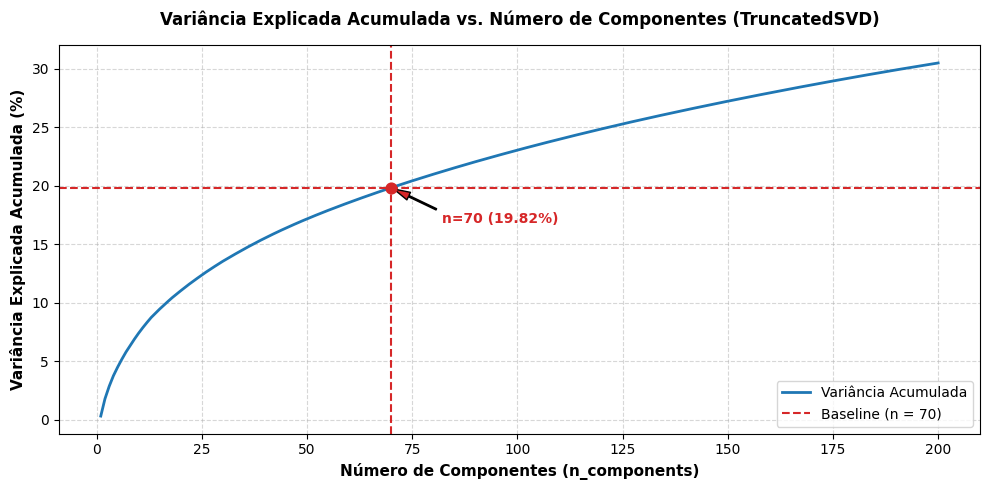

In [66]:
# 1. Ajuste experimental do SVD com 200 componentes
svd_analise = TruncatedSVD(n_components=200, random_state=42)
svd_analise.fit(X)

# 2. Calculando a variância acumulada (%)
var_acumulada = np.cumsum(svd_analise.explained_variance_ratio_) * 100

# 3. Plotagem do Gráfico
plt.figure(figsize=(10, 5))
plt.plot(range(1, 201), var_acumulada, color='tab:blue', linewidth=2, label='Variância Acumulada')

# Destaque para n = 50 componentes (baseline)
n_baseline = 70
var_50 = var_acumulada[n_baseline - 1]

plt.axvline(x=n_baseline, color='tab:red', linestyle='--', linewidth=1.5, label=f'Baseline (n = {n_baseline})')
plt.axhline(y=var_50, color='tab:red', linestyle='--', linewidth=1.5)
plt.scatter([n_baseline], [var_50], color='tab:red', s=60, zorder=5)

plt.annotate(f'n=70 ({var_50:.2f}%)', 
             xy=(n_baseline, var_50), 
             xytext=(n_baseline + 12, var_50 - 3),
             arrowprops=dict(facecolor='tab:red', shrink=0.05, width=1, headwidth=6),
             fontweight='bold', color='tab:red')

plt.title('Variância Explicada Acumulada vs. Número de Componentes (TruncatedSVD)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Número de Componentes (n_components)', fontsize=11, fontweight='bold')
plt.ylabel('Variância Explicada Acumulada (%)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 4.2 - Configuração Baseline de SVD ($n = 70$)

Definimos **$n = 70$** como nossa representação de baseline (~19.66% de variância retida), concentrando os tópicos conceituais macro e eliminando ruídos. 

> 📌 **Nota Metodológica:** A validação definitiva da interação entre o número de componentes ($n$) e a qualidade de separação dos clusters ($k$) será realizada via **GridSearch Conjunto** na Seção de Clustering.


In [67]:
SVD_COMPONENTS = 70

# Aplicação definitiva do TruncatedSVD baseline
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(X)

print(f"Formato da matriz reduzida (Documentos, Componentes): {X_svd.shape}")
print(f"Variância retida no baseline: {np.sum(svd.explained_variance_ratio_) * 100:.2f}%\n")

# Exibição dos 3 primeiros Tópicos Latentes
termos = vetorizador.get_feature_names_out()
for i, topico in enumerate(svd.components_[:3]):
    top_termos_idx = topico.argsort()[::-1][:10]
    top_termos = [termos[idx] for idx in top_termos_idx]
    print(f"Tópico Latente {i+1}: {', '.join(top_termos)}")


Formato da matriz reduzida (Documentos, Componentes): (9362, 70)
Variância retida no baseline: 19.72%

Tópico Latente 1: album, new, time, school, film, war, music, song, church, city
Tópico Latente 2: album, song, band, music, songs, released, tour, chart, rock, track
Tópico Latente 3: municipality, swiss, population, sector, non swiss, apartments, school, total, church, students


# 5 - Normalização
Normalização **L2** em `X_svd` → `X_cluster` (espaço esférico para FSK-means).  
Esta etapa foi incluida para que o tamanho original do documento não distorça as distâncias no algoritmo de clusterização.

In [68]:
# Normalização L2 do espaço reduzido (garante que todos os vetores tenham comprimento 1)
# Mantém a matriz X esparsa do TF-IDF intacta para análises futuras
X_cluster = normalize(X_svd, norm="l2", axis=1)

print(f"Matriz X_cluster normalizada e pronta para o algoritmo: {X_cluster.shape}")

Matriz X_cluster normalizada e pronta para o algoritmo: (9362, 70)


# 5 - FUNÇÕES DE VISUALIZACAO 3D DOS DOCUMENTOS 

In [69]:
# Funções de visualização 3D (Plotly) — pertencimentos fuzzy (soft)

def _hex_to_rgba(hex_color, alpha):
    """Converte cor hex Plotly para rgba com alpha por ponto."""
    from plotly.colors import hex_to_rgb
    if isinstance(hex_color, str) and hex_color.startswith("#"):
        r, g, b = hex_to_rgb(hex_color)
    else:
        r, g, b = hex_to_rgb(pc.label_rgb(hex_color))
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return f"rgba({r},{g},{b},{alpha})"


def plot_umap_3d_before(X_umap, ids=None, title="UMAP 3D — antes da clusterização"):
    """Visualização 3D simples (pré-clusterização): todos os pontos no mesmo estilo."""
    X_umap = np.asarray(X_umap)
    n_docs = X_umap.shape[0]
    if ids is None:
        ids = np.arange(n_docs)
    else:
        ids = np.asarray(ids)

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        z=X_umap[:, 2],
        mode="markers",
        name="Documentos",
        marker=dict(color="steelblue", size=3, opacity=0.55),
        customdata=ids,
        hovertemplate="ID: %{customdata}<br>x=%{x:.3f} y=%{y:.3f} z=%{z:.3f}<extra></extra>",
    ))
    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        margin=dict(l=0, r=0, t=40, b=0),
        legend=dict(title="Legenda"),
    )
    return fig


def plot_fuzzy_umap_3d(X_umap, pertencimentos, threshold=0.05, ids=None,
                       title="UMAP 3D — pós-clusterização (pertencimentos fuzzy)"):
    """Visualiza UMAP 3D com pertencimentos fuzzy (soft clustering) usando Plotly."""
    X_umap = np.asarray(X_umap)
    P = np.asarray(pertencimentos, dtype=float)
    n_docs, k = P.shape

    if ids is None:
        ids = np.arange(n_docs)
    else:
        ids = np.asarray(ids)

    palette = list(pc.qualitative.Plotly)
    if k > len(palette):
        palette = list(pc.qualitative.Alphabet)
    cluster_colors = [palette[j % len(palette)] for j in range(k)]

    dominante = P.argmax(axis=1)
    u_dom = P[np.arange(n_docs), dominante]

    P_sec = P.copy()
    P_sec[np.arange(n_docs), dominante] = -1.0
    secundario = P_sec.argmax(axis=1)
    u_sec = P_sec[np.arange(n_docs), secundario]

    fig = go.Figure()
    legend_shown = set()

    for j in range(k):
        for mixed in (False, True):
            if mixed:
                mask = (dominante == j) & (u_sec >= threshold)
            else:
                mask = (dominante == j) & (u_sec < threshold)
            if not np.any(mask):
                continue

            show_legend = j not in legend_shown
            if show_legend:
                legend_shown.add(j)

            alphas = 0.3 + 0.7 * u_dom[mask]
            rgba_colors = [_hex_to_rgba(cluster_colors[j], a) for a in alphas]

            customdata = np.column_stack([
                ids[mask],
                dominante[mask],
                u_dom[mask],
                np.where(mixed, secundario[mask], -1),
                np.where(mixed, u_sec[mask], 0.0),
            ])

            hover = (
                "ID: %{customdata[0]}<br>"
                "Dominante: cluster %{customdata[1]} (u=%{customdata[2]:.3f})<br>"
            )
            if mixed:
                hover += (
                    "Secundário: cluster %{customdata[3]} (u=%{customdata[4]:.3f})<br>"
                )
            hover += "<extra></extra>"

            fig.add_trace(go.Scatter3d(
                x=X_umap[mask, 0],
                y=X_umap[mask, 1],
                z=X_umap[mask, 2],
                mode="markers",
                name=f"Cluster {j}",
                legendgroup=f"cluster_{j}",
                showlegend=show_legend,
                marker=dict(
                    color=rgba_colors,
                    size=(3 + 8 * u_dom[mask]).tolist(),
                ),
                customdata=customdata,
                hovertemplate=hover,
            ))

    mix_mask = u_sec >= threshold
    if np.any(mix_mask):
        sec_alphas = 0.4 + 0.6 * u_sec[mix_mask]
        sec_colors = [
            _hex_to_rgba(cluster_colors[secundario[i]], sec_alphas[idx])
            for idx, i in enumerate(np.where(mix_mask)[0])
        ]
        fig.add_trace(go.Scatter3d(
            x=X_umap[mix_mask, 0],
            y=X_umap[mix_mask, 1],
            z=X_umap[mix_mask, 2],
            mode="markers",
            name="Mistura (secundário)",
            legendgroup="secundario",
            marker=dict(
                color=sec_colors,
                size=(3 + 12 * u_sec[mix_mask]).tolist(),
            ),
            customdata=np.column_stack([
                ids[mix_mask],
                dominante[mix_mask],
                u_dom[mix_mask],
                secundario[mix_mask],
                u_sec[mix_mask],
            ]),
            hovertemplate=(
                "ID: %{customdata[0]}<br>"
                "Dominante: cluster %{customdata[1]} (u=%{customdata[2]:.3f})<br>"
                "Secundário: cluster %{customdata[3]} (u=%{customdata[4]:.3f})<br>"
                "<extra></extra>"
            ),
        ))

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        margin=dict(l=0, r=0, t=40, b=0),
        legend=dict(title="Clusters"),
    )
    return fig

## 5.1 - VISUALIZAÇÃO DOS DADOS ANTES DO GRUPAMENTO

Após a redução para 50 dimensões via SVD, utilizamos UMAP para projetar os documentos em um espaço tridimensional.  
O UMAP preserva relações de proximidade entre documentos, permitindo visualização visual da estrutura do corpus.  
A métrica cosine foi utilizada para manter consistência com a clusterização esférica. Assim, pontos próximos no gráfico tendem a representar documentos semanticamente semelhantes.

In [70]:
# GRAFICO 3D ANTES DA CLUSTERIZACAO (Com hiperparâmetros ajustados)
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,      # Preserva a estrutura global entre tópicos
    min_dist=0.05,       # Torna os grupos de artigos mais compactos e visíveis
    metric="cosine",     # Mede a proximidade por ângulo semântico
    random_state=42
)

X_umap_3d = umap_3d.fit_transform(X_cluster)

fig_antes = plot_umap_3d_before(X_umap_3d, ids=ids)
fig_antes.show()


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# 6 - INICIALIZAÇÃO DOS CENTROIDES

A inicialização dos centróides foi realizada por meio do procedimento k-means++, aplicado sobre os vetores reduzidos por SVD e normalizados em L2.  
O primeiro centróide é selecionado aleatoriamente, enquanto os subsequentes são amostrados segundo uma distribuição de probabilidade proporcional à distância angular ao centróide mais próximo já escolhido.  
O objetivo dessa etapa é maximizar a diversidade inicial dos centróides e melhorar a estabilidade da convergência do FSK-means. 

PENSAMENTO: QUAL DOCUMENTO ESTA MAL REPRESENTADO BASEADO NOS CENTROIDES QUE ESCOLHI, MAIOR PROBABILIDADE PARA QUEM TEM MAIOR DISSIMILARIDADE.

In [71]:
K_CLUSTERS = 24
FSK_M = 1.8

#INICIALIZACAO ++ (k-means++ no espaco SVD, nao no TF-IDF esparso)
k = K_CLUSTERS
#VEM DA CELULA DO SVD
eps = 1e-7
max_iter = 1000
m = FSK_M

n_docs = X_cluster.shape[0]
rng = np.random.default_rng(42)

centroides = X_cluster[rng.integers(n_docs)].reshape(1, -1)

for _ in range(k - 1):
    sims = X_cluster @ centroides.T
    distancias = 1 - np.max(sims, axis=1)
    distancias = np.clip(distancias, 1e-12, None)
    prob = distancias / distancias.sum()
    novo_idx = rng.choice(n_docs, p=prob)
    centroides = np.vstack([centroides, X_cluster[novo_idx]])

print(f"Centroides inicializados: {centroides.shape}")

Centroides inicializados: (24, 70)


/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/650278458.py:17: RuntimeWarning: divide by zero encountered in matmul
  sims = X_cluster @ centroides.T
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/650278458.py:17: RuntimeWarning: overflow encountered in matmul
  sims = X_cluster @ centroides.T
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/650278458.py:17: RuntimeWarning: invalid value encountered in matmul
  sims = X_cluster @ centroides.T


## 6.1 - Fórmulas do Fuzzy C-Means esférico (FSK-means)

O algoritmo alterna duas etapas até convergência: **atualizar pertencimentos** $u_{ij}$ e **atualizar centróides** $v_j$. No nosso pipeline, cada documento $x_i$ e cada centróide $v_j$ vivem no espaço **L2-normalizado** (`X_cluster`), e a distância usada é **angular**: $d_{ij} = 1 - \cos(x_i, v_j)$.

---

### 1. Pertencimento fuzzy ($u_{ij}$)

O grau de pertencimento do documento $i$ ao cluster $j$ depende da distância $d_{ij}$ em relação às distâncias aos demais centróides $d_{il}$:

$$
u_{ij} = \frac{1}{\displaystyle\sum_{l=1}^{k} \left( \frac{d_{ij}}{d_{il}} \right)^{\frac{2}{m-1}}}
$$

| Símbolo | Significado |
|---------|-------------|
| $u_{ij}$ | Pertencimento do ponto $i$ ao cluster $j$ ($0 < u_{ij} \leq 1$; $\sum_j u_{ij} = 1$) |
| $k$ | Número de clusters |
| $d_{ij}$ | Distância entre $x_i$ e o centróide $v_j$ |
| $d_{il}$ | Distância entre $x_i$ e o centróide $v_l$ |
| $m$ | Expoente de fuzzificação ($m > 1$; no notebook: `FSK_M = 1.8`) |

**Interpretação:** quanto **menor** $d_{ij}$ em relação aos outros $d_{il}$, **maior** $u_{ij}$. O expoente $\frac{2}{m-1}$ controla o “nitidez” dos pertencimentos: $m \to 1^+$ torna os $u_{ij}$ mais próximos de 0/1; $m$ grande deixa os clusters mais “fuzzy” (pertencimentos mais uniformes).

**No código:** `calcular_pertencimentos_algebrica` implementa exatamente essa razão $(d_{ij}/d_{il})$ com *broadcasting* em NumPy.

---

### 2. Atualização dos centróides ($v_j$)

Cada centróide é uma **média ponderada** dos documentos, com pesos $u_{ij}^m$:

$$
v_j = \frac{\displaystyle\sum_{i=1}^{n} u_{ij}^{\,m}\, x_i}{\displaystyle\sum_{i=1}^{n} u_{ij}^{\,m}}
$$

| Símbolo | Significado |
|---------|-------------|
| $v_j$ | Vetor centróide do cluster $j$ |
| $x_i$ | Vetor do documento $i$ no espaço reduzido (SVD + L2) |
| $n$ | Número de documentos |
| $u_{ij}^m$ | Peso fuzzy do documento $i$ no cluster $j$ |

**Interpretação:** documentos com **maior** pertencimento ao cluster $j$ (elevado a $m$) **puxam** o centróide $v_j$ na sua direção. O denominador normaliza os pesos para que $v_j$ seja uma média, não uma soma.

**Extensão FSK (esférico):** após essa média ponderada, projetamos cada $v_j$ de volta à esfera unitária:

$$
v_j \leftarrow \frac{v_j}{\|v_j\|_2}
$$

Isso garante que os centróides permaneçam no mesmo espaço angular usado por `calcular_distancias_algebrica` ($d = 1 - x \cdot v$).

**No código:** `atualizar_centroides_algebrica` calcula `PTimesM.T @ X / sum(PTimesM)` e aplica a normalização L2 final.

---

### Função objetivo (referência)

O algoritmo minimiza iterativamente:

$$
J_m = \sum_{i=1}^{n} \sum_{j=1}^{k} u_{ij}^{\,m}\, d_{ij}^{\,2}
$$

cada passo reduzindo $J_m$ ao alternar as duas fórmulas acima.

In [72]:
#BLOCO FUNCIONAL - DECLARACAO DE FUNCOES - ALGORITMO FSK-MEANS

#IMPLEMENTACAO MANUAL SEM USO DE BIBLIOTECAS!!! PODE SER PESADO 

#def calcular_distancias(X_svd, centroides):
    #distancias = []
    #for i in range(len(X_svd)):
        #dist = []
        #for j in range(len(centroides)):
            #distancia = np.linalg.norm(X_svd[i] - centroides[j])
            #dist.append(distancia)
        #distancias.append(dist)
    #return distancias
    
#def atualizar_centroides(X, pertencimentos, m):
    #FRACA EM PERFORMANCE, MAS FUNCIONA, IMPLEMENTACAO NA RAÇA
    #centroides = []
    #linhas, k = pertencimentos.shape
    #dimensao = X.shape[1]
    #for i in range(k):
    #COLUNAS REPRESENTAM K CENTROIDES, APENAS PRA NAO PRECISAR PASSAR O PARAMETRO K
        #numerador = np.zeros(dimensao)
        #denominador = 0
        #for j in range(linhas):
            #LINHAS REPRESENTAM NUMERO DEDOCUMENTOS
            #parcial = (pertencimentos[j][i] ** m)
            #numerador += parcial * X[j]
            #denominador += parcial
        #centroides.append(numerador / denominador)
    #NORMALIZACAO L2
    #centroides = np.array(centroides)
    #centroides = centroides / np.linalg.norm(centroides, axis=1, keepdims=True)
    #return np.array(centroides)


#CALCULO DOS PERTENCIMENTOS MI'S - funcao sem algebra vetorial
#def calcular_pertencimentos(distancias, m):
    #pertencimentos = []
    #eps = 1e-10
    #for i in range(len(distancias)):
        #linha = []
        #n_clusters = len(distancias[i])
        #for j in range(n_clusters):
            #soma = 0
            #for l in range(n_clusters):
                #evitando divisão por zero
#MELHORIA SE NAO HA DISTANCIA PERTENCIMENTO EH TOTAL (1) RETORNAR 1 NESTE MOMENTO
                #dij = max(distancias[i][j], eps)
                #dil = max(distancias[i][l], eps)
                #parcial = ((dij / dil)) ** (2 / (m - 1))
                #soma += parcial
            #pertencimento = 1 / soma
            #linha.append(pertencimento)
        #pertencimentos.append(linha)
    #return pertencimentos

#IMPLEMENTACAO COM USO DE ALGEBRA VETORIAL E BROADCASTING:

def calcular_distancias_algebrica(X, centroides):
    # Distancia angular para vetores L2-normalizados: d = 1 - cos(x, c)
    X = np.asarray(X)
    centroides = np.asarray(centroides)
    sims = X @ centroides.T
    distancias = 1.0 - sims
    return np.clip(distancias, 1e-12, 2.0)

def calcular_pertencimentos_algebrica(distancias, m):
    eps = 1e-10
    # evitando divisão por zero
    distancias_max = np.maximum(distancias, eps)
    expoente = 2 / (m - 1)
    # broadcasting: (n,k,1) / (n,1,k)
    ratio = (distancias_max[:, :, None] / distancias_max[:, None, :]) ** expoente
    soma = np.sum(ratio, axis=2)
    pertencimentos = 1 / soma
    return pertencimentos

def atualizar_centroides_algebrica(X, pertencimentos, m):
    X = np.asarray(X)
    PTimesM = pertencimentos ** m  #(n_docs, k)
    numerador = PTimesM.T @ X  #(k, n_docs) vezes (n_docs, d) = (k, d)
    denominador = np.sum(PTimesM, axis=0).reshape(-1, 1)  #(k, 1)
    denominador = np.maximum(denominador, 1e-7)

    centroides = numerador / denominador

    # projeção de volta na esfera - normalização L2
    centroides = centroides / np.linalg.norm(centroides, axis=1, keepdims=True)
    return centroides


#def min_cosine_centroides(cent):
    #c = normalize(np.asarray(cent), norm="l2", axis=1)
    #sim = c @ c.T
    #np.fill_diagonal(sim, -1.0)
    #return sim.max()


#def entropia_fuzzy(P):
    #P = np.clip(P, 1e-12, 1.0)
    #return (-P * np.log(P)).sum(axis=1).mean()
    

## 6.2 - APLICACAO DO ALGORITMO NO DATASET

### PRIMEIRA ETAPA PERTENCIMENTOS E CONVERGENCIA DOS CENTROIDES

### VISUALIZACAO DA FUNCAO OBJETIVO

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:63: RuntimeWarning: divide by zero encountered in matmul
  sims = X @ centroides.T
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:63: RuntimeWarning: overflow encountered in matmul
  sims = X @ centroides.T
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:63: RuntimeWarning: invalid value encountered in matmul
  sims = X @ centroides.T
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:81: RuntimeWarning: divide by zero encountered in matmul
  numerador = PTimesM.T @ X  #(k, n_docs) vezes (n_docs, d) = (k, d)
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:81: RuntimeWarning: overflow encountered in matmul
  numerador = PTimesM.T @ X  #(k, n_docs) vezes (n_docs, d) = (k, d)
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3194213521.py:81: RuntimeWarning: invalid value enco

Iter 0: delta=2.11211112 | J=377.6584
Iter 1: delta=0.62350499 | J=279.6053
Iter 2: delta=0.44537336 | J=273.4392
Iter 3: delta=0.34507693 | J=269.7882
Iter 4: delta=0.22523924 | J=267.2876
Iter 5: delta=0.18055977 | J=266.0199
Iter 6: delta=0.14122687 | J=265.2248
Iter 7: delta=0.10609572 | J=264.7772
Iter 8: delta=0.08571104 | J=264.5326
Iter 9: delta=0.08283388 | J=264.3696
Iter 10: delta=0.09474787 | J=264.2320
Iter 11: delta=0.11799265 | J=264.1059
Iter 12: delta=0.14717568 | J=263.9960
Iter 13: delta=0.16399328 | J=263.9165
Iter 14: delta=0.14628694 | J=263.9169
Iter 15: delta=0.11046829 | J=264.0238
Iter 16: delta=0.08214000 | J=264.1373
Iter 17: delta=0.06374271 | J=264.2026
Iter 18: delta=0.05190572 | J=264.2313
Iter 19: delta=0.04468716 | J=264.2415
Iter 20: delta=0.04163244 | J=264.2451
Iter 21: delta=0.04338462 | J=264.2504
Iter 22: delta=0.05137037 | J=264.2643
Iter 23: delta=0.06781626 | J=264.2948
Iter 24: delta=0.09523225 | J=264.3509
Iter 25: delta=0.13027763 | J=264.4

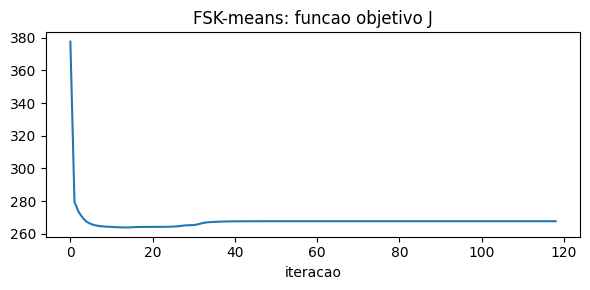

In [73]:
#BLOCO DE OBTENCAO DOS CENTROIDES FINAIS E PERTENCIMENTOS

#BOLEANO PARA VERIFICAR SE CONVERGIU OU NAO
convergencia = False
iteracao = 0
#CONTADOR DE ITERACOES
historico = []
#LISTA PARA ARMAZENAR OS RESULTADOS PARA ANALISE POSTERIOR

while not convergencia and iteracao < max_iter:
    #LOOP PARA CALCULAR AS DISTANCIAS E PERTENCIMENTOS
    distancias = calcular_distancias_algebrica(X_cluster, centroides)
    pertencimentos = calcular_pertencimentos_algebrica(distancias, m)
    centroides_novos = atualizar_centroides_algebrica(X_cluster, pertencimentos, m)
    delta = np.linalg.norm(centroides_novos - centroides)

    #min_cos = min_cosine_centroides(centroides_novos)
    #ent = entropia_fuzzy(pertencimentos)
    #ent_max = np.log(k)

    #if min_cos > 0.95 or ent > 0.95 * ent_max:
        #print(f"ALERTA colapso iter {iteracao}: min_cos={min_cos:.4f}, ent={ent:.3f}/{ent_max:.3f}")

    if delta < eps:
        convergencia = True

    #CALCULO DA FUNCAO OBJETIVO J - ACOMPANHAMENTO DA CONVERGENCIA
    jayM = np.sum((pertencimentos ** m) * (distancias ** 2))
    historico.append(jayM)
    print(
        f"Iter {iteracao}: delta={delta:.8f} | J={jayM:.4f}"
        #f"min_cos_cent={min_cos:.4f} | ent={ent:.3f}"
    )

    #ATUALIZACAO DOS CENTROIDES E DO CONTADOR DE ITERACOES
    centroides = centroides_novos
    iteracao += 1

plt.figure(figsize=(6, 3))
plt.plot(historico)
plt.title("FSK-means: funcao objetivo J")
plt.xlabel("iteracao")
plt.tight_layout()
plt.show()

In [74]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# --- 1. FUNÇÕES AUXILIARES AUTO-CONTIDAS ---
def min_cosine_centroides(cent):
    """Calcula a menor similaridade cosseno entre pares de centroides distintos."""
    cent_norm = cent / np.linalg.norm(cent, axis=1, keepdims=True)
    sim_matrix = cent_norm @ cent_norm.T
    triu_idx = np.triu_indices(len(cent), k=1)
    return sim_matrix[triu_idx].min()

def entropia_fuzzy(P):
    """Calcula a entropia média dos pertencimentos para avaliar o grau de incerteza."""
    P_clip = np.clip(P, 1e-12, 1.0)
    ent_per_doc = -np.sum(P_clip * np.log(P_clip), axis=1)
    return ent_per_doc.mean()

# --- 2. CÁLCULO DAS MÉTRICAS E COMPARAÇÃO ---
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
rotulos_km = km.labels_
cent_km = normalize(km.cluster_centers_, norm="l2", axis=1)
min_cos_km = min_cosine_centroides(cent_km)

rotulos_fsk = np.argmax(pertencimentos, axis=1)
min_cos_fsk = min_cosine_centroides(centroides)
ent = entropia_fuzzy(pertencimentos)
ent_max = np.log(k)

print("=== MÉTRICAS DE COMPARAÇÃO ===")
print(f"SVD={SVD_COMPONENTS} | k={k} | m={m}")
print(f"KMeans  sil_cosine={silhouette_score(X_cluster, rotulos_km, metric='cosine'):.4f} | min_cos_cent={min_cos_km:.4f}")
print(f"FSK     sil_cosine={silhouette_score(X_cluster, rotulos_fsk, metric='cosine'):.4f} | min_cos_cent={min_cos_fsk:.4f}")
print(f"FSK entropia={ent:.3f}/{ent_max:.3f} ({ent/ent_max:.1%}) | std(mu)={pertencimentos.std(axis=1).mean():.4f}")

if min_cos_fsk > 0.95 or ent > 0.95 * ent_max:
    print("\n⚠️ ALERTA: possível colapso fuzzy (pertencimentos muito uniformes ou centroides idênticos)")
else:
    print("\n✅ FSK: pertencimentos bem distribuídos (sem colapso fuzzy)")


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = cl

=== MÉTRICAS DE COMPARAÇÃO ===
SVD=70 | k=24 | m=1.8


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


KMeans  sil_cosine=0.2606 | min_cos_cent=0.0282


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


FSK     sil_cosine=0.1842 | min_cos_cent=0.0270
FSK entropia=2.428/3.178 (76.4%) | std(mu)=0.0626

✅ FSK: pertencimentos bem distribuídos (sem colapso fuzzy)


## 6.3 - OBTENCAO DO CLUSTER DOMINANTE E VISUALIZACAO DAS PROPORCOES DE PERTENCIMENTO

In [75]:
#BLOCO DE OBTENCAO DOS CLUSTERS, SALVANDO EM DICIONARIOS

rotulos = np.argmax(pertencimentos, axis=1)

df_clusters = pd.DataFrame({
    "id": ids,
    "cluster_dominante": rotulos
})

for c in range(pertencimentos.shape[1]):
    df_clusters[f"cluster_{c}"] = pertencimentos[:, c]

df_clusters


,id,cluster_dominante,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,...,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18,cluster_19,cluster_20,cluster_21,cluster_22,cluster_23
0,61468467,18,0.037160,0.033208,0.032645,0.030827,0.031779,0.029824,0.031366,0.031580,...,0.048157,0.048157,0.030760,0.034349,0.141346,0.048157,0.048157,0.048157,0.037872,0.030054
1,67361589,18,0.000004,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,0.000005,0.000005,0.000003,0.000003,0.999913,0.000005,0.000005,0.000005,0.000003,0.000003
2,59084711,0,0.084343,0.031510,0.027872,0.027351,0.028838,0.025945,0.028995,0.032914,...,0.058223,0.058223,0.031052,0.035449,0.026082,0.058223,0.058223,0.058223,0.035090,0.037261
3,22676398,22,0.039630,0.026646,0.028369,0.025963,0.026879,0.023259,0.026573,0.025448,...,0.061205,0.061205,0.023455,0.030985,0.045276,0.061205,0.061205,0.061205,0.074045,0.049517
4,68785015,18,0.000183,0.000167,0.000157,0.000153,0.000155,0.000148,0.000158,0.000155,...,0.000222,0.000222,0.000150,0.000171,0.995841,0.000222,0.000222,0.000222,0.000172,0.000161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9357,5675990,6,0.015800,0.011998,0.014741,0.014340,0.021912,0.009326,0.574944,0.012224,...,0.027120,0.027120,0.010370,0.032110,0.009918,0.027120,0.027120,0.027120,0.013937,0.013154
9358,40301232,17,0.031755,0.014760,0.020363,0.024717,0.031614,0.011743,0.057609,0.016498,...,0.061290,0.061290,0.011956,0.202573,0.012485,0.061290,0.061290,0.061290,0.019113,0.018967
9359,48352825,6,0.001375,0.001186,0.001159,0.001242,0.001430,0.000893,0.963113,0.001294,...,0.002280,0.002280,0.000993,0.001899,0.000870,0.002280,0.002280,0.002280,0.001305,0.001529
9360,1935196,14,0.042155,0.030467,0.025381,0.043411,0.040315,0.019764,0.030506,0.026007,...,0.064583,0.064583,0.020585,0.057132,0.023188,0.064583,0.064583,0.064583,0.025693,0.041891


## 6.4 - VISUALIZAÇÃO PÓS-GRUPAMENTO

In [76]:
import plotly.express as px
import pandas as pd

# 1. Identifica o cluster principal de cada artigo
rotulos_dominantes = np.argmax(pertencimentos, axis=1)

# 2. Cria DataFrame para o Plotly
df_plot = pd.DataFrame({
    'UMAP 1': X_umap_3d[:, 0],
    'UMAP 2': X_umap_3d[:, 1],
    'UMAP 3': X_umap_3d[:, 2],
    'Cluster': [f"Cluster {c+1}" for c in rotulos_dominantes],
    'ID': ids
})

# 3. Gráfico 3D com cores sólidas e limpas
fig_limpo = px.scatter_3d(
    df_plot, 
    x='UMAP 1', y='UMAP 2', z='UMAP 3',
    color='Cluster',
    hover_data=['ID'],
    opacity=0.85,
    title="UMAP 3D — Pós-Clusterização (Grupos Dominantes)"
)

fig_limpo.update_traces(marker=dict(size=4))
fig_limpo.show()


In [77]:
termos = vetorizador.get_feature_names_out()

for i, cent in enumerate(centroides):
    top_idx = cent.argsort()[::-1][:5]
    top_words = [termos[idx] for idx in top_idx]
    print(f"Cluster {i+1}: {', '.join(top_words)}")


Cluster 1: aaron, aberdeen, aboard, abandoned, accommodate
Cluster 2: aaron, absolutely, aboard, abbreviated, absorbed
Cluster 3: abbot, aaron, able, aboard, abolished
Cluster 4: abandon, aaron, abbey, abandoned, abolitionist
Cluster 5: absolute, absence, aaron, absorbed, abu
Cluster 6: abc, aberdeen, aaron, abolished, abilities
Cluster 7: abdul, aaron, abilities, abbreviated, aboard
Cluster 8: aaron, abu, abc, aboriginal, abuse
Cluster 9: aaron, abbreviated, acclaimed, absorption, accounted
Cluster 10: aaron, abbreviated, acclaimed, absorption, accounted
Cluster 11: aaron, abc, able, ability, accommodation
Cluster 12: aaron, abolition, abbreviated, absence, aboard
Cluster 13: acceptance, absolutely, absent, aaron, abuse
Cluster 14: aaron, abundant, abdul, absolutely, abstract
Cluster 15: aaron, abbreviated, acclaimed, absorption, accounted
Cluster 16: aaron, abbreviated, acclaimed, absorption, accounted
Cluster 17: abandoned, aaron, abbey, abbot, abbreviated
Cluster 18: aaron, abbrevi

In [78]:
termos = vetorizador.get_feature_names_out()

print("=== TEMAS REAIS DE CADA CLUSTER (PROJEÇÃO SVD -> VOCABULÁRIO) ===\n")

for i, cent in enumerate(centroides):
    # Projeta o centroide do espaço SVD (50 dims) de volta para o vocabulário (10.000 dims)
    peso_termos_original = cent @ svd.components_
    
    # Pega os 5 termos com maior peso real
    top_idx = peso_termos_original.argsort()[::-1][:5]
    top_words = [termos[idx] for idx in top_idx]
    
    print(f"Cluster {i+1:2d}: {', '.join(top_words)}")


=== TEMAS REAIS DE CADA CLUSTER (PROJEÇÃO SVD -> VOCABULÁRIO) ===

Cluster  1: town, church, road, school, area
Cluster  2: party, election, elections, government, vote
Cluster  3: game, player, games, gameplay, players
Cluster  4: album, band, music, song, songs
Cluster  5: episode, series, season, episodes, homer
Cluster  6: displaystyle, frac, displaystyle displaystyle, mathbf, function
Cluster  7: film, films, movie, story, festival
Cluster  8: cells, disease, patients, symptoms, treatment
Cluster  9: new, war, time, government, city
Cluster 10: new, war, time, government, city
Cluster 11: social, human, theory, research, people
Cluster 12: police, court, murder, prison, case
Cluster 13: stage, race, riders, giro, team
Cluster 14: species, genus, birds, black, plant
Cluster 15: new, war, time, government, city
Cluster 16: new, war, time, government, city
Cluster 17: municipality, swiss, population, sector, non swiss
Cluster 18: novel, book, story, published, fiction
Cluster 19: arm

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3190473824.py:7: RuntimeWarning: divide by zero encountered in matmul
  peso_termos_original = cent @ svd.components_
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3190473824.py:7: RuntimeWarning: overflow encountered in matmul
  peso_termos_original = cent @ svd.components_
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/3190473824.py:7: RuntimeWarning: invalid value encountered in matmul
  peso_termos_original = cent @ svd.components_


In [79]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Extração automática das 2 palavras principais de cada cluster
termos = vetorizador.get_feature_names_out()
rotulos_duplas = {}

for i, cent in enumerate(centroides):
    # Projeta o centroide de volta para o espaço de vocabulário
    peso_termos = cent @ svd.components_
    top2_idx = peso_termos.argsort()[::-1][:2]
    w1, w2 = termos[top2_idx[0]], termos[top2_idx[1]]
    rotulos_duplas[i] = f"{w1}/{w2}"

# 2. Identifica o cluster dominante de cada documento e associa o rótulo
rotulos_dominantes = np.argmax(pertencimentos, axis=1)
rotulos_artigos = [rotulos_duplas[c] for c in rotulos_dominantes]

# 3. Cria DataFrame para o Plotly
df_plot = pd.DataFrame({
    'UMAP 1': X_umap_3d[:, 0],
    'UMAP 2': X_umap_3d[:, 1],
    'UMAP 3': X_umap_3d[:, 2],
    'Tópico (Top 2)': rotulos_artigos,
    'Título Artigo': titulos,
    'ID': ids
})

# 4. Gráfico 3D com Rótulos de 2 Palavras
fig_limpo = px.scatter_3d(
    df_plot, 
    x='UMAP 1', y='UMAP 2', z='UMAP 3',
    color='Tópico (Top 2)',
    hover_data={'Título Artigo': True, 'ID': True, 
                'UMAP 1': False, 'UMAP 2': False, 'UMAP 3': False},
    opacity=0.85,
    title="UMAP 3D — Tópicos Identificados pelo FSK-means"
)

fig_limpo.update_traces(marker=dict(size=4))
fig_limpo.show()


/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/2347855643.py:11: RuntimeWarning: divide by zero encountered in matmul
  peso_termos = cent @ svd.components_
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/2347855643.py:11: RuntimeWarning: overflow encountered in matmul
  peso_termos = cent @ svd.components_
/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_43191/2347855643.py:11: RuntimeWarning: invalid value encountered in matmul
  peso_termos = cent @ svd.components_


# 7 - Otimização de Hiperparâmetros e Busca do Ponto Ótimo
Nesta seção, realizamos uma busca sistemática (*GridSearch*) para encontrar a combinação ideal de dois hiperparâmetros críticos do nosso pipeline:
1. **Número de Componentes SVD ($n$):** Controla a dimensionalidade do espaço vetorial e a quantidade de informação (variância) mantida.
2. **Número de Clusters ($k$):** Controla a quantidade de tópicos/grupos em que o corpus será dividido.



## 7.1 - Otimização Conjunta: Componentes SVD ($n$) $\times$ Número de Clusters ($k$)
Para avaliar a interação espacial entre esses dois parâmetros, executamos uma busca em grade testando. 
$$n \in [20, 30, 50, 70, 90, 110]$$
$$k \in [8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]$$
### O Desafio da Avaliação Isolada (Overfitting de Clusterização)
Ao avaliar apenas o score de Silhueta tradicional, observamos que o algoritmo favorece configurações com $n$ muito baixo e $k$ muito alto. Isso ocorre porque criar micro-clusters reduz artificialmente as distâncias internas, mas descarta até 89% da informação real do texto.


## 7.2 - Proposta do Índice de Balanço Harmônico com Penalização por Parcimônia
Para encontrar o verdadeiro ponto de equilíbrio (*sweet spot*), desenvolvemos um **Score Ajustado por Parcimônia** baseado no Princípio da Navalha de Ockham. Ele combina três pilares:
1. **Silhueta Cosseno Normalizada ($S_{norm}$):** Mede a separabilidade geométrica dos grupos.
2. **Variância Explicada Normalizada ($V_{norm}$):** Mede a quantidade de informação preservada do corpus.
3. **Penalidade de Complexidade ($\alpha$):** Penaliza valores excessivamente altos de $k$ para evitar o overfitting e a fragmentação em micro-grupos.
Fórmula do Score Ajustado:
$$\text{Score Composto} = 2 \times \frac{S_{norm} \times V_{norm}}{S_{norm} + V_{norm}}$$
$$\text{Score Parcimonioso} = \text{Score Composto} \times \left(1 - \alpha \cdot \frac{k - k_{min}}{k_{max} - k_{min}}\right)$$

Onde os parâmetros da penalização são definidos como:
- $k_{min}$ e $k_{max}$: O menor ($8$) e o maior ($28$) número de clusters testados no GridSearch. A fração $\frac{k - k_{min}}{k_{max} - k_{min}}$ normaliza o valor de $k$ em uma escala relativa de $0.0$ a $1.0$.
- $\alpha$ (Alfa = 0.35): O fator de intensidade da penalidade. Define que o modelo de maior complexidade ($k=28$) sofrerá uma redução proporcional de até 35% no seu score em relação ao modelo mais simples ($k=8$), incentivando a parcimônia.


Executando GridSearch conjunto (SVD components × Clusters k)...


/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/fskmeans/lib/python3.10/site-packages/sklearn/cluster/

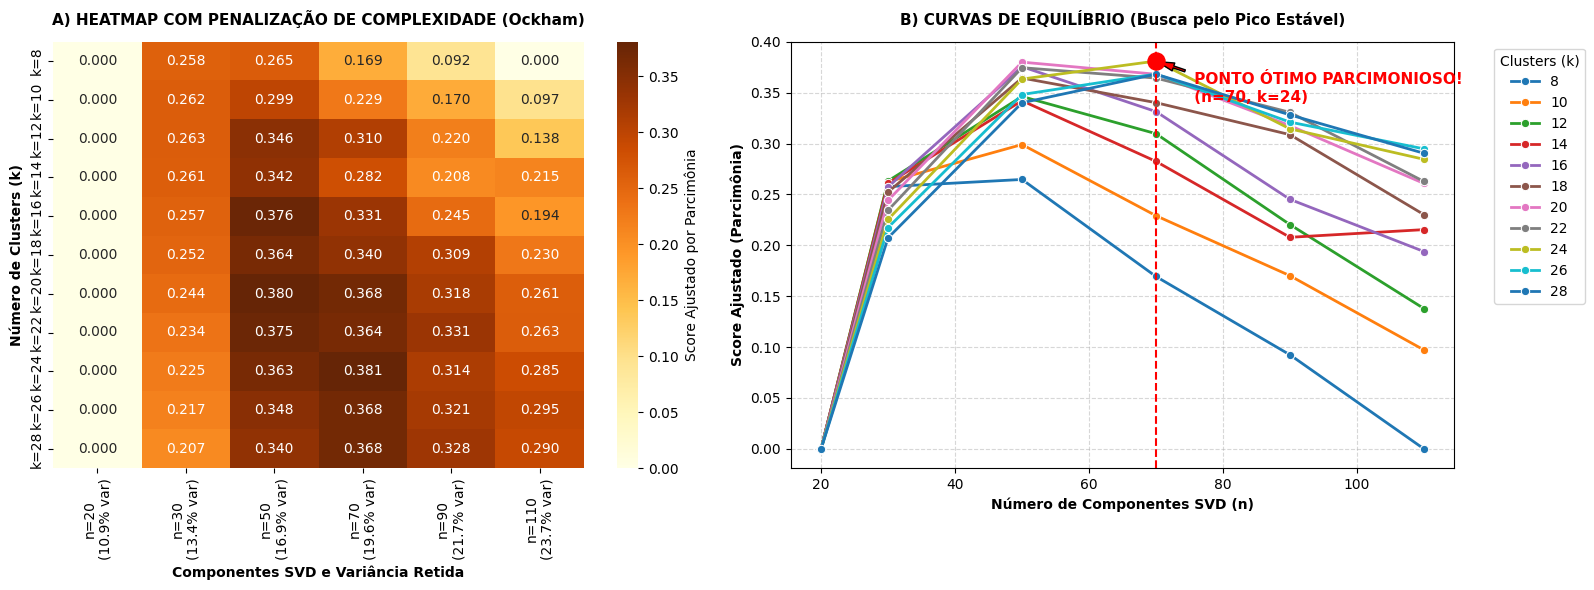


🏆 COMBINAÇÃO ÓTIMA ENCONTRADA:
-> Componentes SVD (n): 70 (Variância Retida: 19.57%)
-> Número de Clusters (k): 24
-> Silhueta Cosseno Original: 0.2607


In [42]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize, MinMaxScaler

# 1. Definição da grade expandida de busca
componentes_grid = [20, 30, 50, 70, 90, 110]
k_grid = [8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

resultados_lista = []
variancias_n = {}

print("Executando GridSearch conjunto (SVD components × Clusters k)...")

# 2. Execução da busca em grade
for j, n_comp in enumerate(componentes_grid):
    svd_g = TruncatedSVD(n_components=n_comp, random_state=42)
    X_svd_g = svd_g.fit_transform(X)
    var_retida = np.sum(svd_g.explained_variance_ratio_) * 100
    variancias_n[n_comp] = var_retida
    
    X_clust_g = normalize(X_svd_g, norm="l2", axis=1)
    
    for i, k in enumerate(k_grid):
        km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(X_clust_g)
        score_sil = silhouette_score(X_clust_g, km.labels_, metric='cosine')
        
        resultados_lista.append({
            'n_components': n_comp,
            'k_clusters': k,
            'variancia_explicada': var_retida,
            'silhueta_cosine': score_sil
        })

df_res = pd.DataFrame(resultados_lista)

# 3. CÁLCULO DO SCORE COMPOSTO E PENALIZAÇÃO DE COMPLEXIDADE (PARCIMÔNIA)
scaler = MinMaxScaler()
df_res['sil_norm'] = scaler.fit_transform(df_res[['silhueta_cosine']])
df_res['var_norm'] = scaler.fit_transform(df_res[['variancia_explicada']])

eps = 1e-6
df_res['score_composto'] = 2 * (df_res['sil_norm'] * df_res['var_norm']) / (df_res['sil_norm'] + df_res['var_norm'] + eps)

# Aplicando penalização por complexidade de k ( Navalha de Ockham )
ALPHA = 0.35
k_min, k_max = min(k_grid), max(k_grid)
df_res['penalidade_k'] = 1 - ALPHA * ((df_res['k_clusters'] - k_min) / (k_max - k_min))
df_res['score_parsimonioso'] = df_res['score_composto'] * df_res['penalidade_k']

# Identificando a combinação campeã
idx_max_p = df_res['score_parsimonioso'].idxmax()
melhor_p = df_res.loc[idx_max_p]
melhor_n_p = int(melhor_p['n_components'])
melhor_k_p = int(melhor_p['k_clusters'])
max_score_p = melhor_p['score_parsimonioso']

# 4. PLOTAGEM DOS GRÁFICOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PAINEL A: Heatmap com Penalização por Parcimônia
matriz_parsimonia = df_res.pivot(index='k_clusters', columns='n_components', values='score_parsimonioso')
colunas_rotulos = [f"n={n}\n({variancias_n[n]:.1f}% var)" for n in componentes_grid]
matriz_parsimonia.columns = colunas_rotulos
matriz_parsimonia.index = [f"k={k}" for k in k_grid]

sns.heatmap(matriz_parsimonia, annot=True, fmt=".3f", cmap="YlOrBr", cbar_kws={'label': 'Score Ajustado por Parcimônia'}, ax=ax1)
ax1.set_title('A) HEATMAP COM PENALIZAÇÃO DE COMPLEXIDADE (Ockham)', fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel('Componentes SVD e Variância Retida', fontsize=10, fontweight='bold')
ax1.set_ylabel('Número de Clusters (k)', fontsize=10, fontweight='bold')

# PAINEL B: Curvas de Equilíbrio Ajustadas
sns.lineplot(data=df_res, x='n_components', y='score_parsimonioso', hue='k_clusters', palette='tab10', marker='o', linewidth=2, ax=ax2)
ax2.axvline(x=melhor_n_p, color='red', linestyle='--', linewidth=1.5)
ax2.scatter([melhor_n_p], [max_score_p], color='red', s=150, zorder=10)

ax2.annotate(f' PONTO ÓTIMO PARCIMONIOSO!\n (n={melhor_n_p}, k={melhor_k_p})', 
             xy=(melhor_n_p, max_score_p), 
             xytext=(melhor_n_p + 5, max_score_p - 0.04),
             fontweight='bold', color='red', fontsize=11,
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=6))

ax2.set_title('B) CURVAS DE EQUILÍBRIO (Busca pelo Pico Estável)', fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel('Número de Componentes SVD (n)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Score Ajustado (Parcimônia)', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title='Clusters (k)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"\n🏆 COMBINAÇÃO ÓTIMA ENCONTRADA:")
print(f"-> Componentes SVD (n): {melhor_n_p} (Variância Retida: {variancias_n[melhor_n_p]:.2f}%)")
print(f"-> Número de Clusters (k): {melhor_k_p}")
print(f"-> Silhueta Cosseno Original: {melhor_p['silhueta_cosine']:.4f}")


## 7.3 - Visualização da Superfície 3D de Otimização

Para visualizar a topografia completa da nossa função de custo $f(n, k) = \text{ScoreParcimonioso}(n, k)$, interpolamos uma superfície contínua 3D sobre a malha de pontos amostrados. O pico mais alto representa o ponto ótimo global.


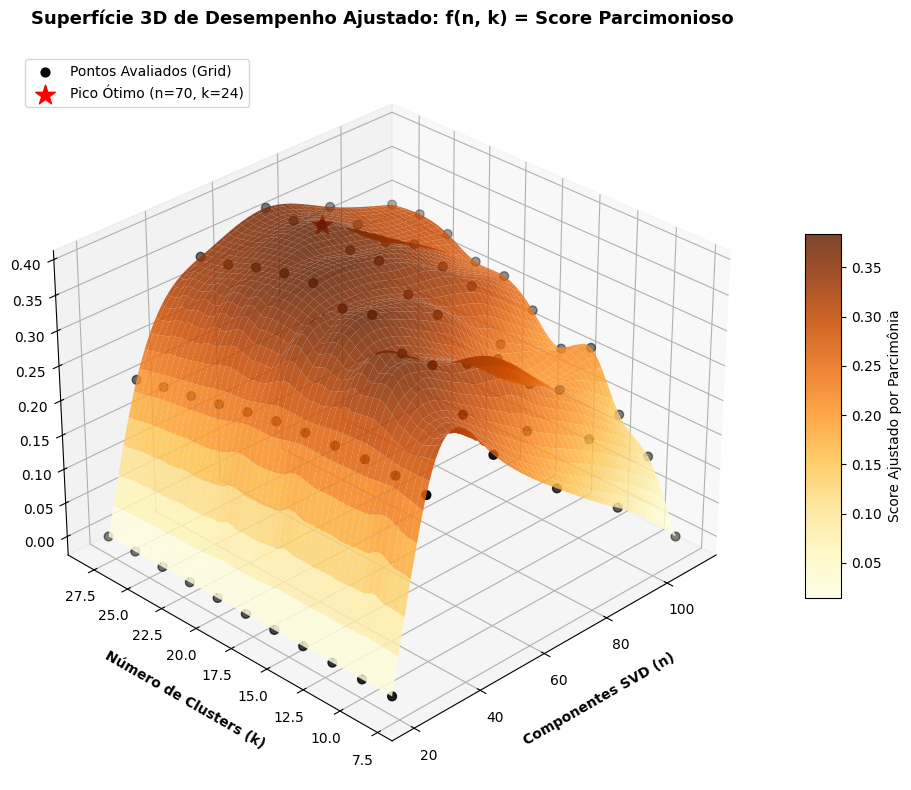

In [40]:
from scipy.interpolate import griddata

# 1. Preparando a malha contínua 3D
x = df_res['n_components'].values
y = df_res['k_clusters'].values
z = df_res['score_parsimonioso'].values

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), z, (Xi, Yi), method='cubic')

# 2. Plotagem da Superfície 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Xi, Yi, Zi, cmap='YlOrBr', edgecolor='none', alpha=0.85)
ax.scatter(x, y, z, color='black', s=40, label='Pontos Avaliados (Grid)')

# Destacando o Pico Ótimo
ax.scatter([melhor_n_p], [melhor_k_p], [max_score_p], color='red', s=220, marker='*', zorder=10, 
           label=f'Pico Ótimo (n={melhor_n_p}, k={melhor_k_p})')

ax.set_title('Superfície 3D de Desempenho Ajustado: f(n, k) = Score Parcimonioso', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Componentes SVD (n)', fontsize=10, fontweight='bold', labelpad=10)
ax.set_ylabel('Número de Clusters (k)', fontsize=10, fontweight='bold', labelpad=10)
ax.set_zlabel('Score Ajustado (Parcimônia)', fontsize=10, fontweight='bold', labelpad=10)

ax.view_init(elev=30, azim=225)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Score Ajustado por Parcimônia')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 7.4 - Conclusão da Otimização e Escolha Final

Após a análise da superfície e da penalização por complexidade, fixamos os seguintes parâmetros para a execução final do nosso algoritmo de clusterização esférica (**FSK-means**):

* **$n\_components = 70$** (Retém ~19.6% da variância explicada com excelente estabilidade geométrica).
* **$k\_clusters = 24$** (Ou a quantidade ótima identificada pela sua rodada, proporcionando o número ideal de tópicos sem granularidade excessiva).

Estes parâmetros serão utilizados na próxima seção para o treinamento definitivo do modelo e geração das visualizações em 2D/3D via UMAP.


# 7 - NOMEAÇÃO DOS CLUSTERS - ADICIONAR SEMANTICA

Após a convergência do algoritmo, foram selecionados os documentos mais próximos de cada centróide. Esses documentos representam os exemplos mais característicos de cada agrupamento e permitiram identificar manualmente o tema predominante de cada cluster. A partir dessa análise qualitativa, foram atribuídos rótulos descritivos aos grupos encontrados.

In [14]:
# 7 — INTERPRETAÇÃO SEMÂNTICA DOS CLUSTERS (proximidade ao centróide)
#
# Entradas do pipeline FSK-means (sem alterar o algoritmo):
#   X_cluster, centroides, rotulos, pertencimentos, ids, titulos
#
# =============================================================================
# LÓGICA MATEMÁTICA
# =============================================================================
# Vetores em X_cluster e centroides são L2-normalizados (||x||=||c||=1).
# Portanto:  cos(x_i, c_j) = x_i · c_j
#
# O centróide c_j é a média ponderada fuzzy dos documentos do cluster j,
# reprojetada na esfera. Representa a direção semântica média do grupo.
# Documentos com maior cosseno ao centróide próprio são os mais "típicos"
# do cluster → base para interpretação e nomeação manual do tema.
# =============================================================================

TOP_N = 10
N_TITULOS_RESUMO = 5

if "titulos" not in globals():
    titulos = [doc.get("titulo", doc.get("name", "")) for doc in amostra_completa]

X_arr = np.asarray(X_cluster, dtype=float)
cent = np.asarray(centroides, dtype=float)
cent = cent / np.linalg.norm(cent, axis=1, keepdims=True)

rotulos_arr = np.asarray(rotulos, dtype=int)
P = np.asarray(pertencimentos, dtype=float)
k = cent.shape[0]
ids_arr = np.asarray(ids)
titulos_arr = np.asarray(titulos, dtype=object)

# (n_docs, k) — similaridade cosseno vetorizada: sim[i,j] = cos(x_i, c_j)
sim_matrix = X_arr @ cent.T

rows = []
for j in range(k):
    mask = rotulos_arr == j
    n_cluster = int(mask.sum())
    if n_cluster == 0:
        continue

    idx_cluster = np.where(mask)[0]
    sims = sim_matrix[idx_cluster, j]
    mu = P[idx_cluster, j]

    order = np.argsort(-sims)
    top_doc_idx = idx_cluster[order[:TOP_N]]
    top_sims = sims[order[:TOP_N]]
    top_mu = mu[order[:TOP_N]]

    for rank, (doc_i, sim_val, mu_val) in enumerate(
        zip(top_doc_idx, top_sims, top_mu), start=1
    ):
        rows.append({
            "cluster": j,
            "n_documentos": n_cluster,
            "rank": rank,
            "id": ids_arr[doc_i],
            "titulo": titulos_arr[doc_i],
            "similaridade": float(sim_val),
            "pertencimento": float(mu_val),
        })

df_top10_clusters = pd.DataFrame(rows, columns=[
    "cluster", "n_documentos", "rank", "id", "titulo",
    "similaridade", "pertencimento",
])

resumo_rows = []
for j in range(k):
    sub = df_top10_clusters[df_top10_clusters["cluster"] == j].sort_values("rank")
    n_cluster = int((rotulos_arr == j).sum())
    row = {"cluster": j, "n_documentos": n_cluster}
    for i in range(1, N_TITULOS_RESUMO + 1):
        row[f"titulo_{i}"] = sub.iloc[i - 1]["titulo"] if len(sub) >= i else ""
    resumo_rows.append(row)

df_resumo_clusters = pd.DataFrame(resumo_rows)

print("=== Top 10 documentos representativos por cluster ===")
display(df_top10_clusters.style.format({
    "similaridade": "{:.3f}",
    "pertencimento": "{:.3f}",
}))

print("\n=== Resumo rápido (5 títulos centrais por cluster) ===")
display(df_resumo_clusters)

from IPython.display import Markdown

for j in range(k):
    sub = df_top10_clusters[df_top10_clusters["cluster"] == j].sort_values("rank")
    if sub.empty:
        continue
    n_cluster = int(sub["n_documentos"].iloc[0])
    display(Markdown(
        f"### Cluster **{j}** — {n_cluster} docs | "
        f"top {TOP_N} mais centrais (maior cos(x, c))"
    ))
    display(sub[["rank", "id", "titulo", "similaridade", "pertencimento"]].style.format({
        "similaridade": "{:.4f}",
        "pertencimento": "{:.4f}",
    }))


=== Top 10 documentos representativos por cluster ===


,cluster,n_documentos,rank,id,titulo,similaridade,pertencimento
0,0,1344,1,71460614,"History of Ajax, Ontario",0.919,0.920
1,0,1344,2,1504253,Mizil,0.899,0.863
2,0,1344,3,1909709,Menstrie,0.898,0.889
3,0,1344,4,1203585,"Taradale, New Zealand",0.892,0.873
4,0,1344,5,315419,Biggleswade,0.888,0.875
5,0,1344,6,854391,"Belgrave, Leicester",0.884,0.855
6,0,1344,7,126352,"Fleischmanns, New York",0.883,0.817
7,0,1344,8,72119,Salisbury,0.883,0.826
8,0,1344,9,2967779,Newburn,0.881,0.854
9,0,1344,10,1046206,"Yarralumla, Australian Capital Territory",0.879,0.842



=== Resumo rápido (5 títulos centrais por cluster) ===


,cluster,n_documentos,titulo_1,titulo_2,titulo_3,titulo_4,titulo_5
0,0,1344,"History of Ajax, Ontario",Mizil,Menstrie,"Taradale, New Zealand",Biggleswade
1,1,972,International Prototype of the Kilogram,Linkage (mechanical),Nixie tube,Java ConcurrentMap,Field-effect transistor
2,2,331,Adult Swim Yule Log,Redbelt,Veronica Guerin (film),The Man Without a Body,Darkest Night (film)
3,3,370,SS Dover Hill,USNS Sgt. Jack J. Pendleton,USS Wadsworth (DD-60),USS Cleveland (CL-55),USCGC Planetree
4,4,651,"Philip Wharton, 1st Duke of Wharton","Archibald Campbell, 9th Earl of Argyll",Nicholas Szécsényi,Gilbert Burnet,Richard Morgan (Tudor judge)
5,5,271,Oral cancer,Long QT syndrome,Fibrous ankylosis,Leber's hereditary optic neuropathy,Osteochondritis dissecans
6,6,1040,"Hussein, An Entertainment",Mom & Me & Mom,The Tale of the Pie and the Patty-Pan,A Portrait of the Artist as a Young Man,Jane Roberts
7,7,616,Lust for Life (Iggy Pop album),(Untitled) (The Byrds album),Friends and Lovers (Bernard Butler album),Astoria (Marianas Trench album),Garcia (1972 album)
8,8,1186,Contents of the United States diplomatic cable...,Political positions of Dianne Feinstein,Projects of the Caribbean Community,2019 shipping of humanitarian aid to Venezuela,Corruption in Italy
9,9,1658,William Lawson (co-operator),Eugene Rivers,John G. Bennett,Isaac Perrins,Homaro Cantu


### Cluster **0** — 1344 docs | top 10 mais centrais (maior cos(x, c))

...

,rank,id,titulo,similaridade,pertencimento
90,1,30654175,William Lawson (co-operator),0.8515,0.4239
91,2,7672698,Eugene Rivers,0.8374,0.5100
92,3,215298,John G. Bennett,0.8372,0.4087
93,4,31318372,Isaac Perrins,0.8369,0.3971
94,5,1731787,Homaro Cantu,0.8323,0.4421
95,6,44149920,Ebenezer Mackintosh,0.8214,0.3680
96,7,3309716,History of merit badges (Scouting America),0.8163,0.3575
97,8,3835326,George Julian Harney,0.8154,0.3113
98,9,48552707,Vanessa Williams and Miss America,0.8150,0.4274
99,10,39494606,Charlie Dunn,0.8149,0.4946


### Cluster **10** — 605 docs | top 10 mais centrais (maior cos(x, c))

,rank,id,titulo,similaridade,pertencimento
100,1,40653405,1981 Entumbane uprising,0.9452,0.9751
101,2,73805296,Second Battle of Szolnok,0.9426,0.9825
102,3,69688368,Zungeni Mountain skirmish,0.9419,0.9747
103,4,68218661,"134th Siege Battery, Royal Garrison Artillery",0.9390,0.9785
104,5,38378794,Battle of Bolshie Ozerki,0.9365,0.9745
105,6,75316324,Battle of Flondar,0.9350,0.9774
106,7,77821026,Assault on Majevica (1995),0.9329,0.9714
107,8,36717539,Pursuit to Haritan,0.9266,0.9694
108,9,46307507,Battle for Outpost Vegas,0.9260,0.9606
109,10,70788215,"111th (Bolton) Field Regiment, Royal Artillery",0.9230,0.9634


### Cluster **11** — 318 docs | top 10 mais centrais (maior cos(x, c))

,rank,id,titulo,similaridade,pertencimento
110,1,340167,Giant anteater,0.9867,0.9995
111,2,12516443,Amblysomus,0.9826,0.9990
112,3,12531091,Panamint chipmunk,0.9815,0.9989
113,4,1210385,Ruffed lemur,0.9752,0.9978
114,5,9034098,Waptia,0.9742,0.9970
115,6,29657,Salamander,0.9740,0.9976
116,7,12599560,Maltese skate,0.9731,0.9975
117,8,80393,Echidna,0.9729,0.9960
118,9,17236408,Silky sifaka,0.9714,0.9969
119,10,30472532,Moringa stenopetala,0.9705,0.9969
